In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)[::-1]
    fenotipo = np.zeros((Nind, Nvar))
    
    for i in range(Nind):
        for j in range(Nvar):
            bits = genotipo[i, (j * Lvar):(j * Lvar + Lvar)]
            fenotipo[i, j] = np.sum(potencias * bits)
            
    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / ((2 ** Lvar) - 1)) * fenotipo[:, i]
        
    return fenotipo

def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        objv[i, 0] = 21.5 + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0]) + fenotipo[i, 1] * np.sin(20 * np.pi * fenotipo[i, 1])
    return objv

def rankeo(objv, direccion):
    SP = 2
    Nind = objv.shape[0]
    aptitud = np.zeros((Nind, 1))
    
    if direccion == 1:
        posori = np.argsort(objv, axis=0)
    else:
        posori = np.argsort(-1 * objv, axis=0)
        
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[posori.flatten(), 0] = apt
    return aptitud

def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)
    
    for i in range(Nind):
        selecciona = np.random.rand()
        aux_idx = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux_idx[0]
        
    nuevo_gen = genotipo[idx.flatten(), :]
    return nuevo_gen

def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind), dtype=int)
    par = Nind % 2
    
    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind - 1)
            aux_gen[i] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]
            
    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]
        
    return aux_gen

def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    muta_matrix = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, muta_matrix).astype(int)
    return nuevo_gen

In [13]:
# Definición de parámetros
Nind = 100
Lind = 34  # Ajustado a par para división simétrica de variables
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2
rango = np.array([[-3.0, 12.1], [4.1, 5.8]])

# Inicialización
genotipo = creapob(Nind, Lind)
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

generaciones = 0

# Ciclo evolutivo
while generaciones < Maxgen:
    fenotipo = decodifica(genotipo, rango)
    objv = objfun(fenotipo)
    
    # Guardar la mejor solución de la generación
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    
    # Operadores genéticos
    aptitud = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    
    genotipo = nuevo_gen
    generaciones += 1

idx_global = np.nanargmax(Mejor)
print(f"Mejor valor de f(x,y) encontrado: {Mejor[idx_global, 0]:.4f}")

Mejor valor de f(x,y) encontrado: 38.8436


### Grafica con AG

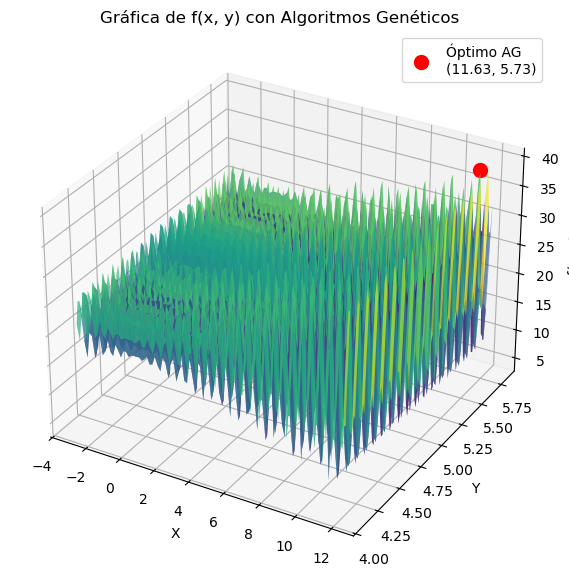

In [14]:
# Gráfica de la función mostrando el resultado óptimo del Algoritmo Genético
x_vals = np.linspace(-3, 12.1, 100)
y_vals = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 21.5 + X * np.sin(4 * np.pi * X) + Y * np.sin(20 * np.pi * Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

# Punto óptimo encontrado por el AG
mejor_feno = decodifica(np.array([Mejor_cromosoma[idx_global]]), rango)
opt_x = mejor_feno[0, 0]
opt_y = mejor_feno[0, 1]
opt_z = Mejor[idx_global, 0]

ax.scatter(opt_x, opt_y, opt_z, color='red', s=100, label=f'Óptimo AG\n({opt_x:.2f}, {opt_y:.2f})', zorder=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) con Algoritmos Genéticos')
plt.legend()
plt.show()


### Grafica sin usar AG

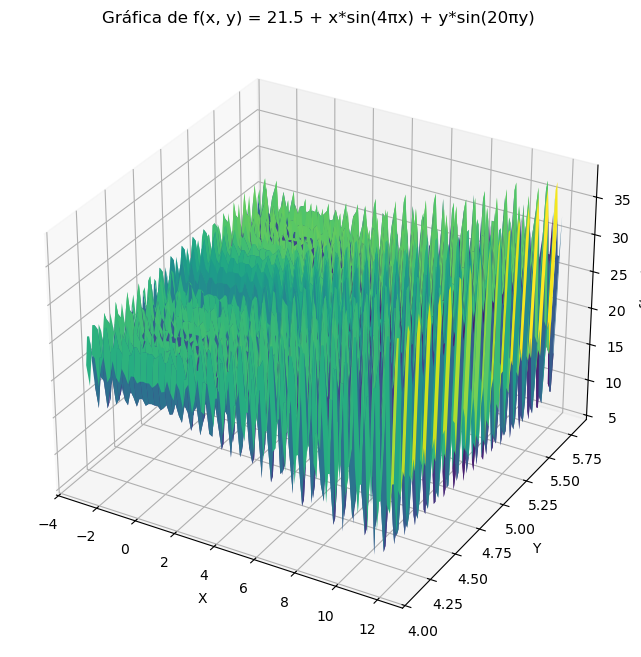

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x = np.linspace(-3, 12.1, 100)
y = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x*sin(4πx) + y*sin(20πy)')

plt.show()